# SETUP

In [1]:
pip install pandas requests matplotlib seaborn jupyter

Defaulting to user installation because normal site-packages is not writeable

   ------------- -------------------------- 2/6 [lark]
   ------------- -------------------------- 2/6 [lark]
   --------------------------------- ------ 5/6 [isoduration]
   ---------------------------------------- 6/6 [isoduration]

Note: you may need to restart the kernel to use updated packages.


In [51]:
# stock price and earning details data is retrieved from the API.
import pandas as pd
from src.fetch_data import get_stock_data, get_earnings_data

stock_df = get_stock_data("AAPL")
earnings_df = get_earnings_data("AAPL")
earning_df

,symbol,date,epsActual,epsEstimated,revenueActual,revenueEstimated,lastUpdated,earning_surpise
122,AAPL,1995-07-20,0.00746,0.00787,2.575000e+09,2.575000e+09,1995-07-20,-0.00041
120,AAPL,1996-01-17,-0.00501,-0.00316,3.148000e+09,1.574000e+09,1996-01-17,-0.00185
119,AAPL,1996-04-17,-0.02000,-0.01422,2.185000e+09,1.560714e+09,1996-04-17,-0.00578
118,AAPL,1996-10-16,-0.00231,-0.00106,2.179000e+09,4.386690e+09,1996-10-16,-0.00125
116,AAPL,1997-01-15,-0.01000,-0.00674,2.129000e+09,1.419333e+09,1997-01-15,-0.00326
...,...,...,...,...,...,...,...,...
5,AAPL,2025-01-30,2.40000,2.36000,1.243000e+11,1.242574e+11,2025-01-30,0.04000
4,AAPL,2025-05-01,1.65000,1.63000,9.535900e+10,9.454218e+10,2025-05-01,0.02000
3,AAPL,2025-07-31,1.57000,1.44000,9.403600e+10,8.956274e+10,2025-07-31,0.13000
2,AAPL,2025-10-30,1.85000,1.78000,1.024660e+11,1.022271e+11,2025-10-30,0.07000


# Cleaning

In [47]:
# check info
stock_df.info()
earning_df.info()

# change datatype
stock_df["date"] = pd.to_datetime(stock_df["date"],errors = "coerce")
earning_df["date"] = pd.to_datetime(earning_df["date"],errors = "coerce")
earning_df["lastUpdated"] = pd.to_datetime(earning_df["date"],errors = "coerce")

# check null values
stock_df.isnull().sum()
earning_df.isnull().sum()

# drop the null values
earning_df = earning_df.dropna()

# sort the table by date
stock_df = stock_df.sort_values("date")
earning_df = earning_df.sort_values("date")

# keep important data
clean_stock = stock_df[["date","open","high","low","close","volume"]]
clean_stock

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   symbol         1255 non-null   object        
 1   date           1255 non-null   datetime64[ns]
 2   open           1255 non-null   float64       
 3   high           1255 non-null   float64       
 4   low            1255 non-null   float64       
 5   close          1255 non-null   float64       
 6   volume         1255 non-null   int64         
 7   change         1255 non-null   float64       
 8   changePercent  1255 non-null   float64       
 9   vwap           1255 non-null   float64       
dtypes: datetime64[ns](1), float64(7), int64(1), object(1)
memory usage: 98.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162 entries, 0 to 161
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 

,date,open,high,low,close,volume
1254,2021-03-18,122.8800,123.1800,120.32,120.53,121469755
1253,2021-03-19,119.9000,121.4300,119.68,119.99,185549522
1252,2021-03-22,120.3300,123.8700,120.26,123.39,111912300
1251,2021-03-23,123.3300,124.2400,122.14,122.54,95467142
1250,2021-03-24,122.8200,122.9000,120.07,120.09,88530500
...,...,...,...,...,...,...
4,2026-03-11,261.0900,262.1300,259.55,260.81,26218927
3,2026-03-12,258.6600,258.9500,254.18,255.76,40794020
2,2026-03-13,255.4800,256.3300,249.52,250.12,36929988
1,2026-03-16,252.1100,253.8900,249.88,252.82,32074209


# Feature Engineering

In [48]:
# add daily return percentage
clean_stock["daily_return"] = clean_stock["close"].pct_change()

# add volatility
clean_stock["volatility"] = clean_stock["daily_return"].rolling(5).std()

# find Earning per share
earning_df["earning_surpise"] = earning_df["epsActual"] - earning_df["epsEstimated"]
earning_df


C:\Users\Suraj\AppData\Local\Temp\ipykernel_13984\570059819.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_stock["daily_return"] = clean_stock["close"].pct_change()
C:\Users\Suraj\AppData\Local\Temp\ipykernel_13984\570059819.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_stock["volatility"] = clean_stock["daily_return"].rolling(5).std()


,symbol,date,epsActual,epsEstimated,revenueActual,revenueEstimated,lastUpdated,earning_surpise
122,AAPL,1995-07-20,0.00746,0.00787,2.575000e+09,2.575000e+09,1995-07-20,-0.00041
120,AAPL,1996-01-17,-0.00501,-0.00316,3.148000e+09,1.574000e+09,1996-01-17,-0.00185
119,AAPL,1996-04-17,-0.02000,-0.01422,2.185000e+09,1.560714e+09,1996-04-17,-0.00578
118,AAPL,1996-10-16,-0.00231,-0.00106,2.179000e+09,4.386690e+09,1996-10-16,-0.00125
116,AAPL,1997-01-15,-0.01000,-0.00674,2.129000e+09,1.419333e+09,1997-01-15,-0.00326
...,...,...,...,...,...,...,...,...
5,AAPL,2025-01-30,2.40000,2.36000,1.243000e+11,1.242574e+11,2025-01-30,0.04000
4,AAPL,2025-05-01,1.65000,1.63000,9.535900e+10,9.454218e+10,2025-05-01,0.02000
3,AAPL,2025-07-31,1.57000,1.44000,9.403600e+10,8.956274e+10,2025-07-31,0.13000
2,AAPL,2025-10-30,1.85000,1.78000,1.024660e+11,1.022271e+11,2025-10-30,0.07000


# Event Window Analysis

In [49]:
results = []

for i in earning_df["date"]:
    window = clean_stock[
        (clean_stock["date"] >= i - pd.Timedelta(days=5)) &
        (clean_stock["date"] <= i + pd.Timedelta(days=5))
    ]  
    window = window.sort_values("date")

    if len(window) > 0:    
        price_before = window.iloc[0]["close"]
        price_after = window.iloc[-1]["close"] 
        price_change = (price_after - price_before) / price_before

        results.append({
            "earnings_date": i,
            "price_before": price_before,
            "price_after": price_after,
            "price_change": price_change
        })

results_df = pd.DataFrame(results)

# Earnings Price Reaction

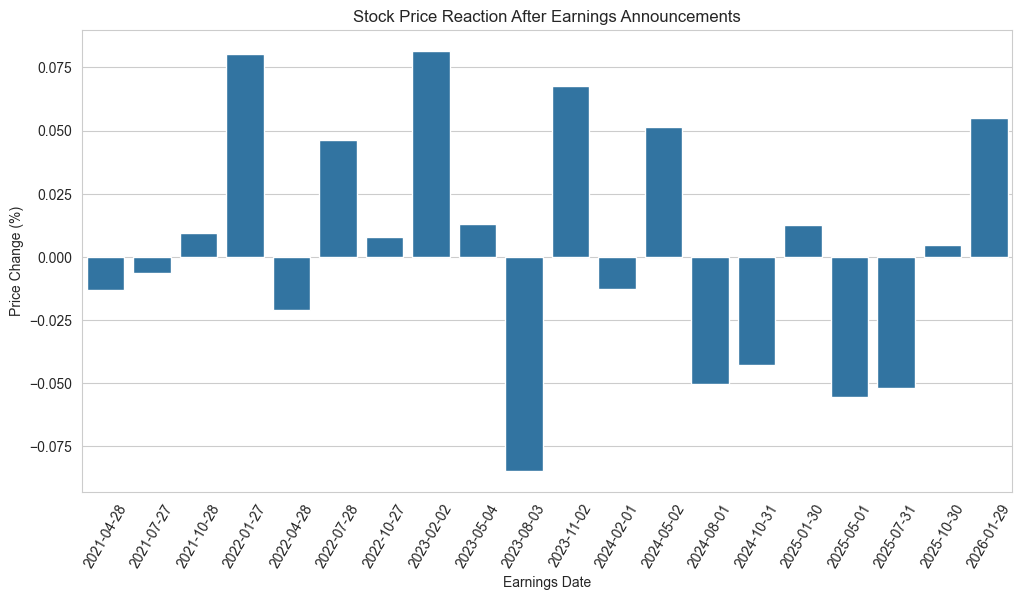

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    x="earnings_date",
    y="price_change",
    data=results_df
)

plt.xticks(rotation=60)
plt.title("Stock Price Reaction After Earnings Announcements")
plt.xlabel("Earnings Date")
plt.ylabel("Price Change (%)")

plt.show()

# Distribution of Earnings Impact

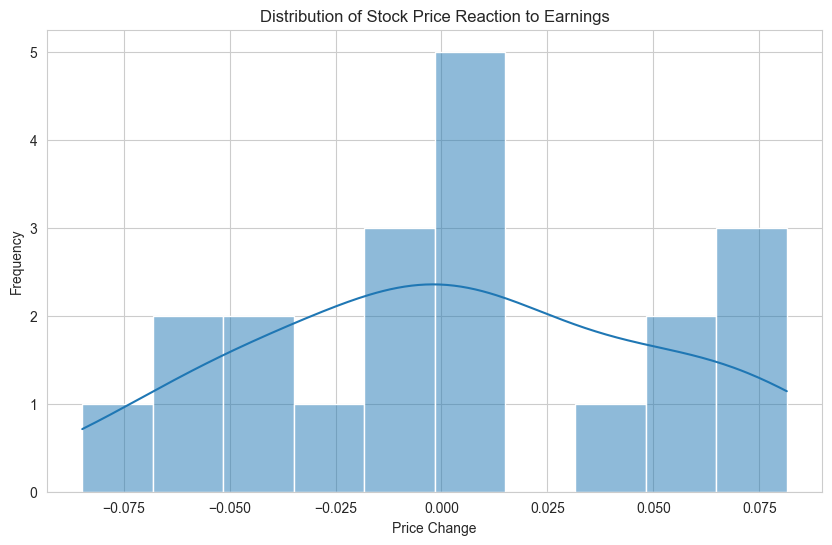

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(results_df["price_change"], bins=10, kde=True)

plt.title("Distribution of Stock Price Reaction to Earnings")
plt.xlabel("Price Change")
plt.ylabel("Frequency")

plt.show()

# Before vs After Price Comparison

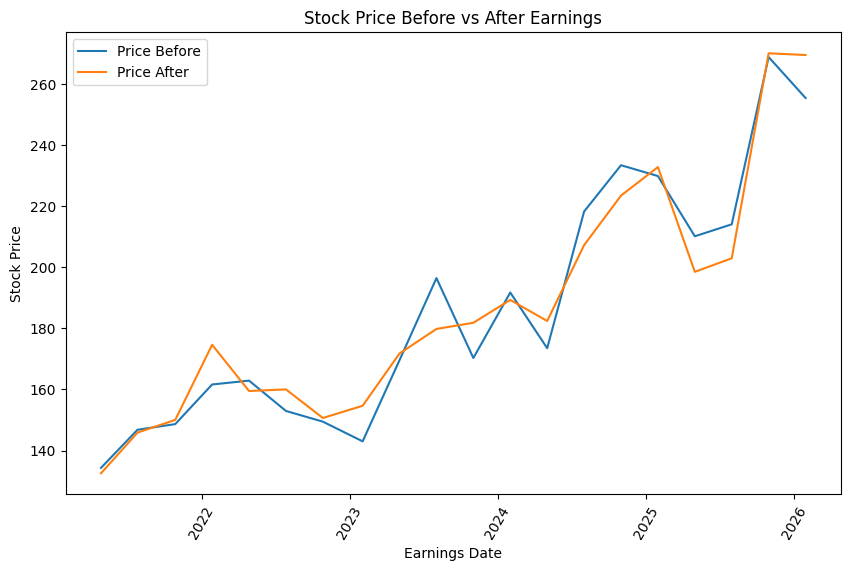

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

plt.plot(results_df["earnings_date"], results_df["price_before"], label="Price Before")
plt.plot(results_df["earnings_date"], results_df["price_after"], label="Price After")

plt.xticks(rotation=60)

plt.title("Stock Price Before vs After Earnings")
plt.xlabel("Earnings Date")
plt.ylabel("Stock Price")
plt.legend()

plt.show()

# Average Market Reaction

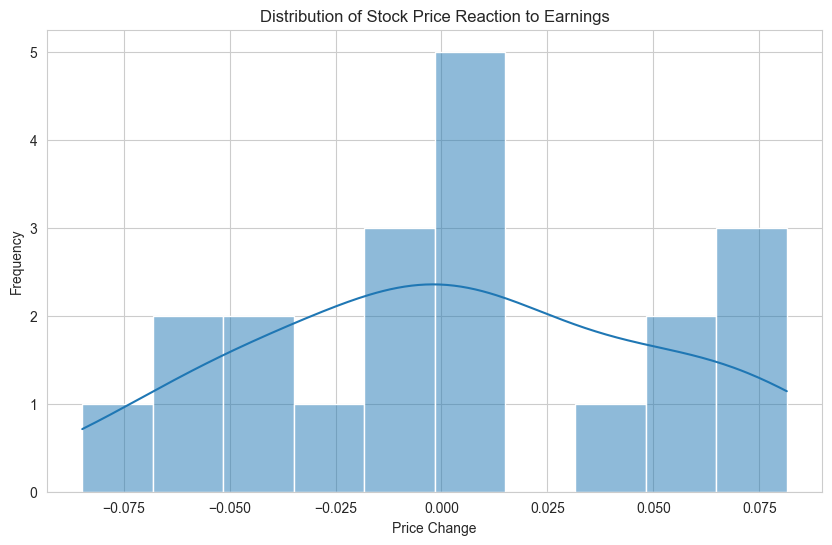

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10,6))

sns.histplot(results_df["price_change"], bins=10, kde=True)

plt.title("Distribution of Stock Price Reaction to Earnings")
plt.xlabel("Price Change")
plt.ylabel("Frequency")

plt.show()